# Lab: Pandas practice with a new dataset
This Lab gives you practice doing groupbys, filtering, and plotting with a new dataset in Pandas.

**NOTE \#1: It is *highly* recommended that you hit "Save & Grade" after you answer each prompt in order to catch any errors in order.**

**NOTE \#2: Make sure you don't accidentally overwrite any of the variables.**

## Setup

<p>Read in the dataframe with <code>df = pd.read_csv('labfiles/dataframe.csv')</code>. <b>Make sure this variable is called <code>df</code>.</b></p><p>Make sure you set any values labeled <code>None</code> or 'None' to NaN.</p>

In [1]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
import pandas as pd
import numpy as np

df = pd.read_csv('labfiles/dataframe.csv', na_values=['None'])


print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   _id                                      2000 non-null   int64  
 1   License Type                             2000 non-null   object 
 2   Description                              2000 non-null   object 
 3   License Number                           1986 non-null   object 
 4   License Status                           2000 non-null   object 
 5   Business                                 2000 non-null   object 
 6   Title                                    20 non-null     object 
 7   First Name                               1918 non-null   object 
 8   Middle                                   732 non-null    object 
 9   Last Name                                1918 non-null   object 
 10  Prefix                                   0 non-n

## Format the data

<h3>Data Cleaning &amp; Data Formatting</h3><h4>1. Cleaning missing data</h4><p>Depending on what questions you choose (like with the buildings dataset that we used in class) there may be some missing data. You should set the <code>na_values</code> input parameter for values of 'None' in any of the columns you want to use for your assignment.  </p><p>For example, we set 0 values of 'Square Footage', 'Year Acquired' &amp; 'Year Constructed' to NA's in the buildings dataset in class.  In this case, instead of searching for 0's in your columns, you might want to look for 'None' or None in your columns.</p><h4>2. Formatting Date columns and getting year/month/day columns.</h4><p>You will need to get the month and/or year out of these date columns ('Original Issue Date','Effective Date','Expiration Date','LastModifiedDate','Discipline End Date').  You can do this in two steps.<ol><li>First, you can convert each date column, for example:<pre>   licenses = df.copy()</pre><pre>   licenses['Original Issue Date'] = pd.to_datetime(licenses['Original Issue Date'],errors='coerce',format='%m/%d/%Y')</pre>will convert the Original Issue Date column.</li><li>Then you can create a new year-column for the 'Original Issue Date' with:<pre>   licenses['Original Issue Year'] = licenses['Original Issue Date'].dt.year</pre></p></li><b>Make sure you name any Year columns with 'Date' replaced by 'Year', any Month columns with 'Date' replaced by 'Month', and any Day columns with 'Date' replaced with 'Day'.</b>  For example, to add the 'Month' and 'Day' columns to the dataframe (in addition to the 'Year' column calculated above) for 'Original Issue Date' we would use:<pre>   licenses['Original Issue Month'] = licenses['Original Issue Date'].dt.month</pre><pre>   licenses['Original Issue Day'] = licenses['Original Issue Date'].dt.day</pre>This will allow the grader to give you appropriate feedback.</li></ol>

In [2]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)

licenses=df.copy()
date_columns = ['Original Issue Date', 'Effective Date', 'Expiration Date', 'LastModifiedDate', 'Discipline End Date']


for col in date_columns:
    licenses[col] = pd.to_datetime(licenses[col], errors='coerce', format='%m/%d/%Y')
    licenses[col.replace('Date', 'Year')] = licenses[col].dt.year
    licenses[col.replace('Date', 'Month')] = licenses[col].dt.month
    licenses[col.replace('Date', 'Day')] = licenses[col].dt.day

print(licenses.head())

       _id     License Type                      Description License Number  \
0   361007            COSMO           LICENSED COSMETOLOGIST     11066547.0   
1   422430            COSMO           LICENSED COSMETOLOGIST       11141877   
2  1185692  DETECTIVE BOARD  PERMANENT EMPLOYEE REGISTRATION      129440638   
3   899712  DETECTIVE BOARD  PERMANENT EMPLOYEE REGISTRATION    129119891.0   
4  1075728  DETECTIVE BOARD  PERMANENT EMPLOYEE REGISTRATION      129314397   

  License Status Business Title First Name Middle  Last Name  ...  \
0       INACTIVE        N   NaN  BERNICE W    NaN      PAUSE  ...   
1         ACTIVE        N   NaN     DARRYL    NaN    CAMMACK  ...   
2    NOT RENEWED        N   NaN     PRINCE    NaN  ALEXANDER  ...   
3    NOT RENEWED        N   NaN  LILLIAN D    NaN      KELLY  ...   
4         ACTIVE        N   NaN     ANGELA    NaN   RYLANDER  ...   

   Effective Day Expiration Year Expiration Month Expiration Day  \
0            NaN          1999.0          

## Plot #1

### Calculation

<p>Calculate the maximum 'Effective Year' for each 'Controlled Substance Schedule' and <b>save this variable as 'gb1'</b>.</p><p>Note: for this calculation you will need to format the date columns as datetime and extract the year (see Tips &amp; Tricks section for more details).</p><p>Checks will be run assuming the listed column names ('Effective Year' and 'Controlled Substance Schedule') so make sure any columns you create are named accordingly.</p>

In [3]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
gb1 = licenses.groupby('Controlled Substance Schedule')['Effective Year'].max()

gb1

Controlled Substance Schedule
II III             NaN
II III IV V     2022.0
III IV V        1992.0
V                  NaN
Name: Effective Year, dtype: float64

### Figure:

<p>Make a plot showing this relationship using <code>fig_gb1,ax_gb1 = plt.subplots()</code>. <b>Make sure you check your figure/axes names.</b></p><p>Tip: What type of plot do you think is the most appropriate for this type of data?</p>

Text(0, 0.5, 'Maximum Effective Year')

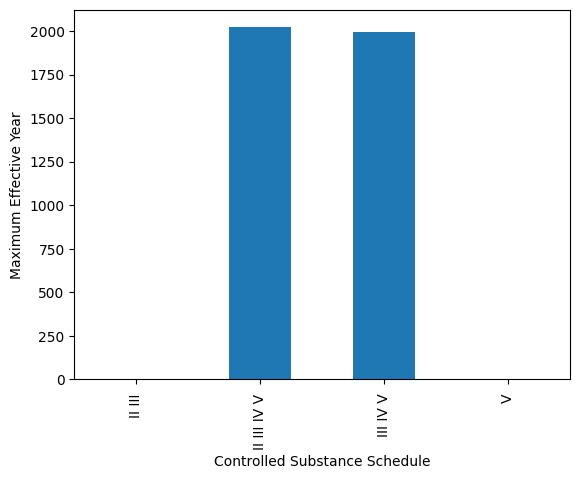

In [4]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
import matplotlib.pyplot as plt 
fig_gb1,ax_gb1 = plt.subplots()
gb1.plot(kind='bar', ax=ax_gb1)
ax_gb1.set_xlabel('Controlled Substance Schedule')
ax_gb1.set_ylabel('Maximum Effective Year')


## Plot #2

### Calculation
<p>Calculate the mean 'Effective Year' for each 'Original Issue Year' and <b>save this variable as 'gb2'</b>.</p><p>Note: for this calculation you will need to format the date columns as datetime and extract the year (see Tips &amp; Tricks section for more details).</p><p>Checks will be run assuming the listed column names ('Effective Year' and 'Original Issue Year') so make sure any columns you create are named accordingly.</p>

In [5]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
gb2 = licenses.groupby('Original Issue Year')['Effective Year'].mean()

gb2

Original Issue Year
1919    1919.000000
1926    1926.000000
1928    1928.000000
1935    1935.000000
1938    1938.000000
           ...     
2018    2019.434783
2019    2019.769231
2020    2020.437500
2021    2021.041667
2022    2022.000000
Name: Effective Year, Length: 83, dtype: float64

### Figure:

<p>Make a plot showing this relationship using <code>fig_gb2,ax_gb2 = plt.subplots()</code>. <b>Make sure you check your figure/axes names.</b></p>

Text(0, 0.5, 'Mean Effective Year')

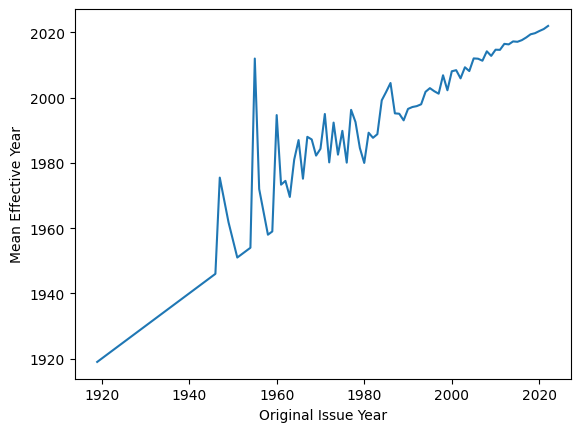

In [6]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
fig_gb2,ax_gb2 = plt.subplots()
gb2.plot(kind='line',ax=ax_gb2)
ax_gb2.set_xlabel('Original Issue Year')
ax_gb2.set_ylabel('Mean Effective Year')

## Plot #3

### Calculation:

<p>Create a dataframe which is a subset of the original dataframe, but contains rows with only the three most common entries in 'County'.</p><p><b>Name this dataframe 'gb3'.</b></p>

In [7]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
top_3_counties = licenses['County'].value_counts().nlargest(3).index

# Create the new dataframe 'gb3' with only rows from these counties
gb3 = licenses[licenses['County'].isin(top_3_counties)]  

gb3

,_id,License Type,Description,License Number,License Status,Business,Title,First Name,Middle,Last Name,...,Effective Day,Expiration Year,Expiration Month,Expiration Day,LastModifiedYear,LastModifiedMonth,LastModifiedDay,Discipline End Year,Discipline End Month,Discipline End Day
1,422430,COSMO,LICENSED COSMETOLOGIST,11141877,ACTIVE,N,NaN,DARRYL,NaN,CAMMACK,...,19.0,2023.0,9.0,30.0,2021,9,19,NaN,NaN,NaN
2,1185692,DETECTIVE BOARD,PERMANENT EMPLOYEE REGISTRATION,129440638,NOT RENEWED,N,NaN,PRINCE,NaN,ALEXANDER,...,8.0,2021.0,9.0,30.0,2022,3,18,NaN,NaN,NaN
3,899712,DETECTIVE BOARD,PERMANENT EMPLOYEE REGISTRATION,129119891.0,NOT RENEWED,N,NaN,LILLIAN D,NaN,KELLY,...,16.0,1994.0,5.0,31.0,2006,8,3,NaN,NaN,NaN
4,1075728,DETECTIVE BOARD,PERMANENT EMPLOYEE REGISTRATION,129314397,ACTIVE,N,NaN,ANGELA,NaN,RYLANDER,...,20.0,2024.0,5.0,31.0,2021,9,20,NaN,NaN,NaN
5,677710,COSMO,LICENSED NAIL TECHNICIAN,169025254,ACTIVE,N,NaN,DOMINIQUE,NGOC,KIRK,...,24.0,2022.0,10.0,31.0,2021,9,24,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,634421,COSMO,LICENSED COSMETOLOGY SCHOOL,13000833.0,ACTIVE,Y,NaN,MYRTLE J,NaN,RANDALL,...,5.0,2022.0,9.0,30.0,2021,7,20,NaN,NaN,NaN
1995,1094755,DETECTIVE BOARD,PERMANENT EMPLOYEE REGISTRATION,129353165,NOT RENEWED,N,NaN,FRANCES M,W,SHORE,...,15.0,2015.0,5.0,31.0,2015,7,14,NaN,NaN,NaN
1996,775217,DETECTIVE BOARD,FIREARM CONTROL CARD,229043621.0,NOT RENEWED,N,NaN,SOPHIE A,NaN,MAUER,...,7.0,1996.0,2.0,24.0,2007,1,19,NaN,NaN,NaN
1997,519486,COSMO,LICENSED COSMETOLOGIST,11253316,NOT RENEWED,N,NaN,KIMBERLY,C,GLAUB,...,29.0,2013.0,9.0,30.0,2013,11,12,NaN,NaN,NaN


### Figure

<p>Using this dataframe, calculate and plot the mean' Original Issue Year' for the three most common entries in 'County' as a function of 'Effective Year'.</p><p>This should be a plot with three different lines, one for each of the three most common entries in 'County'.</p><p>Make the plot showing this relationship using <code>fig_gb3,ax_gb3 = plt.subplots()</code>.</p><p><b>Make sure you check your figure/axes names.</b></p>

Text(0, 0.5, 'Mean Original Issue Year')

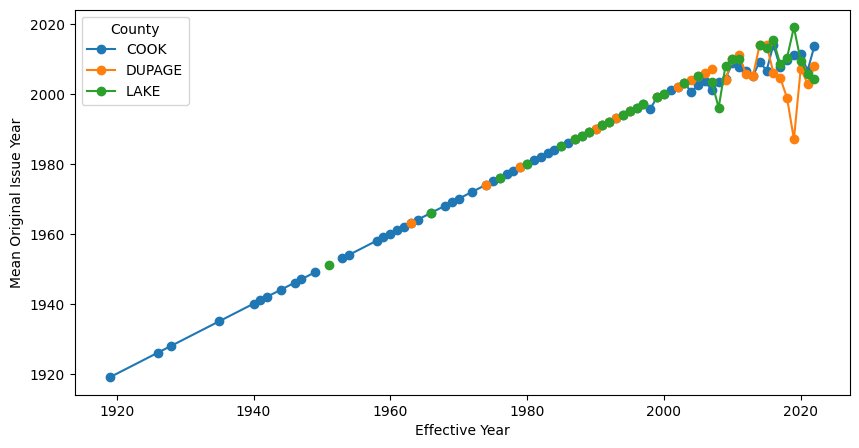

In [9]:
#grade (write your code in this cell and DO NOT DELETE THIS LINE)
gb3_grouped = gb3.groupby(['Effective Year', 'County'])['Original Issue Year'].mean().unstack()


fig_gb3, ax_gb3 = plt.subplots(figsize=(10, 5))


gb3_grouped.plot(ax=ax_gb3, kind='line', marker='o')


ax_gb3.set_xlabel('Effective Year')
ax_gb3.set_ylabel('Mean Original Issue Year')